# Μηχανική Μάθηση - Εργασία 1

##  Άσκηση 1

**Λύση**

In [1]:
import numpy as np
import heapq
from collections import Counter

def knn_gen(xtrain, xtest, ytrain, k):
    # Convert to NumPy arrays
    xtrain = np.asarray(xtrain, dtype=float)
    xtest  = np.asarray(xtest, dtype=float)
    ytrain = np.asarray(ytrain)

    # Normalization
    mini = xtrain.min(axis=0)
    maxi = xtrain.max(axis=0)
    diff = np.where(maxi - mini == 0, 1.0, maxi - mini)

    xtrain_n = (xtrain - mini) / diff
    xtest_n  = (xtest - mini) / diff

    predictions = []

    for i in range(xtest_n.shape[0]):
        max_heap = []  # Max-heap to keep track of k smallest distances

        for j in range(xtrain_n.shape[0]):
            dist = np.linalg.norm(xtrain_n[j] - xtest_n[i])  # Compute Euclidean distance

            if len(max_heap) < k:
                heapq.heappush(max_heap, (-dist, ytrain[j]))  # Store negative distance
            elif -max_heap[0][0] > dist:
                heapq.heappushpop(max_heap, (-dist, ytrain[j]))  # Replace largest if new dist is smaller

        # Extract k nearest labels
        kclass = [label for (_, label) in max_heap]

        # Majority vote
        predicted_class = Counter(kclass).most_common(1)[0][0]
        predictions.append(predicted_class)

    return predictions

## Άσκηση 2

Accuracy for k=1: 48.39%
Accuracy for k=11: 67.74%
Accuracy for k=21: 61.29%
Accuracy for k=51: 67.74%
Accuracy for k=101: 61.29%
Accuracy for k=201: 61.29%
Accuracy for k=301: 61.29%


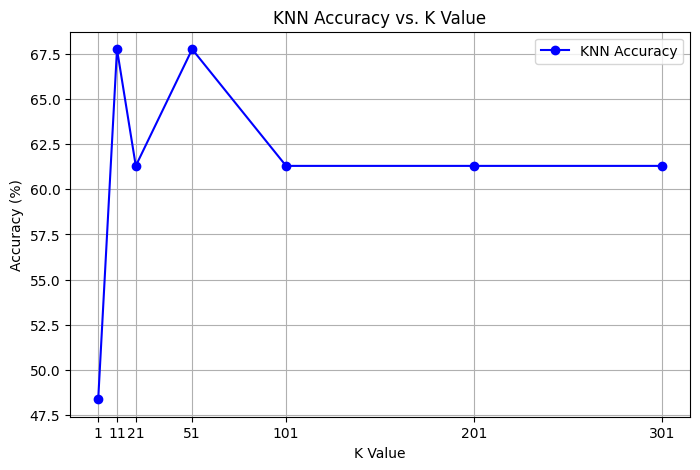

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
%matplotlib inline

# Load the dataset
df_ma = pd.read_csv("data/sa_heart_dataset.csv")

# Data preprocessing
df_ma = df_ma.drop(columns=['famhist'])

train_df, test_df = train_test_split(df_ma, train_size=400, test_size=62, random_state=42)

train = train_df.to_numpy()
test = test_df.to_numpy()

xtrain = train[:, 1:-1]
xtest = test[:, 1:-1]
ytrain = train[:, -1]
ytest = test[:, -1]

# Define the range of k values to test
K=[1,11,21,51,101,201,301]
accuracies = []  # This list will store accuracy for each k

for k in K:
    predictions = knn_gen(xtrain, xtest, ytrain, k)  # Your knn_gen function
    acc = np.mean(np.array(predictions) == ytest) * 100
    accuracies.append(acc)
    print(f"Accuracy for k={k}: {acc:.2f}%")

# Plot
plt.figure(figsize=(8, 5))
plt.plot(K, accuracies, marker='o', linestyle='-', color='b', label="KNN Accuracy")
plt.xlabel("K Value")
plt.ylabel("Accuracy (%)")
plt.title("KNN Accuracy vs. K Value")
plt.xticks(K)  # Label the x-axis ticks using the values in K
plt.grid(True)
plt.legend()
plt.savefig("knn_accuracy_plot.png")  # Save the plot as a PNG file
plt.show()



## Άσκηση 3 (απόσταση Gower)

Accuracy for k=1: 61.29%
Accuracy for k=11: 61.29%
Accuracy for k=21: 67.74%
Accuracy for k=51: 74.19%
Accuracy for k=101: 66.13%
Accuracy for k=201: 61.29%
Accuracy for k=301: 61.29%


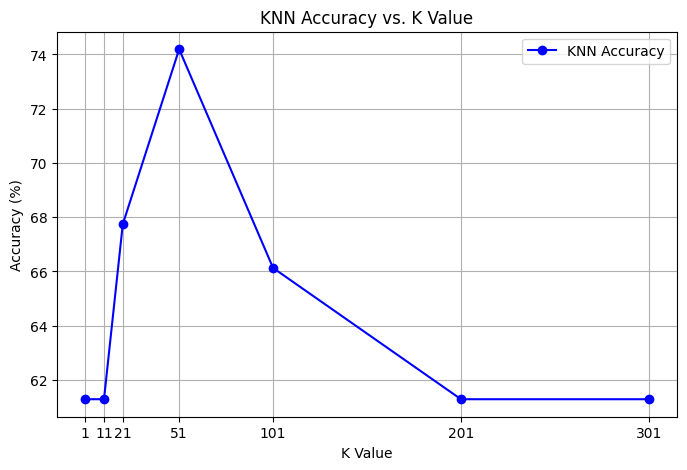

In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import gower  # Import the gower package
import heapq
from collections import Counter

def knn_gen_gower(xtrain, xtest, ytrain, k):
    xtrain = np.asarray(xtrain)
    xtest  = np.asarray(xtest)
    ytrain = np.asarray(ytrain)

    predictions = []

    # Compute Gower distances using the correct function
    distances = gower.gower_matrix(xtest, xtrain)  # Shape: (n_test, n_train)

    for i in range(xtest.shape[0]):
        max_heap = []  # Max-heap to store k smallest distances

        for j in range(xtrain.shape[0]):
            dist = distances[i, j]

            if len(max_heap) < k:
                heapq.heappush(max_heap, (-dist, ytrain[j]))  # Store negative for max-heap behavior
            elif -max_heap[0][0] > dist:
                heapq.heappushpop(max_heap, (-dist, ytrain[j]))  # Replace largest if new dist is smaller

        # Extract k nearest labels
        kclass = [label for _, label in max_heap]

        # Majority voting
        predicted_class = Counter(kclass).most_common(1)[0][0]
        predictions.append(predicted_class)

    return predictions

# Load dataset
df_ma = pd.read_csv("data/sa_heart_dataset.csv")

# Data preprocessing
train_df, test_df = train_test_split(df_ma, train_size=400, test_size=62, random_state=42)

xtrain = train_df.iloc[:, 1:-1].values
xtest  = test_df.iloc[:, 1:-1].values
ytrain = train_df.iloc[:, -1].values
ytest  = test_df.iloc[:, -1].values

# Define the range of k values to test
K = [1, 11, 21, 51, 101, 201, 301]
accuracies = []  # Store accuracy for each k

for k in K:
    predictions = knn_gen_gower(xtrain, xtest, ytrain, k)  # Call knn function
    acc = np.mean(np.array(predictions) == ytest) * 100
    accuracies.append(acc)
    print(f"Accuracy for k={k}: {acc:.2f}%")

# Plot results
plt.figure(figsize=(8, 5))
plt.plot(K, accuracies, marker='o', linestyle='-', color='b', label="KNN Accuracy")
plt.xlabel("K Value")
plt.ylabel("Accuracy (%)")
plt.title("KNN Accuracy vs. K Value")
plt.xticks(K)  # Label x-axis with K values
plt.grid(True)
plt.legend()
plt.savefig("knn_accuracy_plot.png")  # Save the plot
plt.show()

## Άκσηση 3 (με κωδικοποίηση στο 0,1)

Accuracy for k=1: 59.68%
Accuracy for k=11: 62.90%
Accuracy for k=21: 64.52%
Accuracy for k=51: 70.97%
Accuracy for k=101: 66.13%
Accuracy for k=201: 61.29%
Accuracy for k=301: 61.29%


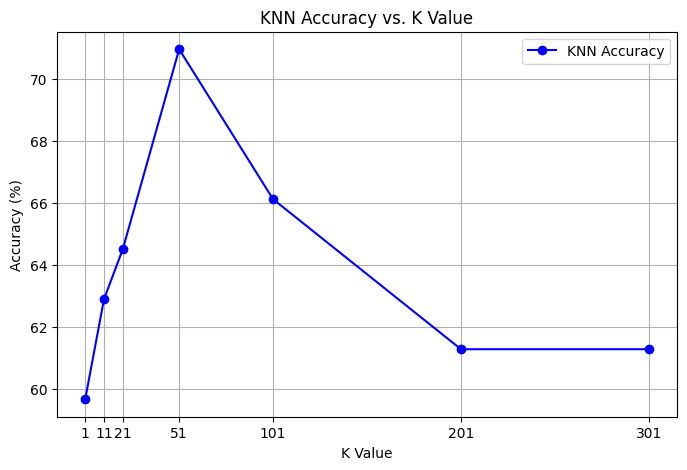

In [4]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
%matplotlib inline

# Load the dataset
df_ma = pd.read_csv("data/sa_heart_dataset.csv")

# Data preprocessing
df_ma['famhist'] = df_ma['famhist'].map({'Present': 1, 'Absent': 0})

train_df, test_df = train_test_split(df_ma, train_size=400, test_size=62, random_state=42)

train = train_df.to_numpy()
test = test_df.to_numpy()

xtrain = train[:, 1:-1]
xtest = test[:, 1:-1]
ytrain = train[:, -1]
ytest = test[:, -1]

# Define the range of k values to test
K=[1,11,21,51,101,201,301]
accuracies = []  # This list will store accuracy for each k

for k in K:
    predictions = knn_gen(xtrain, xtest, ytrain, k)  # Your knn_gen function
    acc = np.mean(np.array(predictions) == ytest) * 100
    accuracies.append(acc)
    print(f"Accuracy for k={k}: {acc:.2f}%")

# Plot
plt.figure(figsize=(8, 5))
plt.plot(K, accuracies, marker='o', linestyle='-', color='b', label="KNN Accuracy")
plt.xlabel("K Value")
plt.ylabel("Accuracy (%)")
plt.title("KNN Accuracy vs. K Value")
plt.xticks(K)  # Label the x-axis ticks using the values in K
plt.grid(True)
plt.legend()
plt.savefig("knn_accuracy_plot.png")  # Save the plot as a PNG file
plt.show()



## Simple implementation

In [5]:
import numpy as np
from collections import Counter

def knn_gen_s(xtrain, xtest, ytrain, k):
    # Convert to NumPy arrays
    xtrain = np.asarray(xtrain, dtype=float)
    xtest  = np.asarray(xtest, dtype=float)
    ytrain = np.asarray(ytrain)

    # Normalization
    mini = xtrain.min(axis=0)
    maxi = xtrain.max(axis=0)
    diff = np.where(maxi - mini == 0, 1.0, maxi - mini)

    xtrain_n = (xtrain - mini) / diff
    xtest_n  = (xtest - mini) / diff

    predictions = []

    for i in range(xtest_n.shape[0]):
        # Compute Euclidean distances
        distances = np.linalg.norm(xtrain_n - xtest_n[i], axis=1)

        # Find the indices of the k smallest distances
        kmin_indices = np.argsort(distances)[:k]

        # Get corresponding labels
        kclass = ytrain[kmin_indices]

        # Majority voting
        predicted_class = Counter(kclass).most_common(1)[0][0]
        predictions.append(predicted_class)

    return predictions
